In [116]:
# !pip install --upgrade typing_extensions --user

# !uv sync

# !uv add ipywidgets 2>&1 | tail -5

In [117]:
# Install uv
# import subprocess
# subprocess.run(["pip", "install", "uv"], check=True)

# Install all project dependencies via uv (much faster than plain pip)
# !uv pip install torch torchvision numpy matplotlib tqdm pillow scipy einops pyyaml wandb tqdm --user

In [118]:
import functools
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from tqdm import trange, tqdm
from torchvision.datasets import FashionMNIST
from torch.optim import Adam
from torch.utils.data import DataLoader

In [119]:
device = torch.device('cuda')
torch.backends.cudnn.benchmark = True

References:

- [[Song21]](https://openreview.net/pdf?id=PxTIG12RRHS) Score-Based Generative Modeling Through Stochastic Differential Equations
- Yang Song's blog

## Variance Preserving SDE (VP)

Variance Preserving diffusion SDE (Eq 11 in [Song21]):

\begin{align*}
d \mathbf{x} = - \frac{1}{2} \beta(t) \mathbf{x} dt + \sqrt{\beta(t)}d\mathbf{w}
\end{align*}

This follows the general SDE form $d \mathbf{x} = f(\mathbf{x}, t) dt + g(t) d \mathbf{w}$. We call $f(\mathbf{x}, t)$ the **drift coefficient** and $g(t)$ the **diffusion coefficient**.

The corresponding general conditional linear Gaussian distribution is:
\begin{align*}
p(x_t|x_0) = \mathcal{N}(x_t; \alpha(t)x_0, \sigma^2(t)I)
\end{align*}
where $\alpha: [0,1] \rightarrow \mathbb{R}$,  $\sigma: [0,1] \rightarrow \mathbb{R}$

$\mu(t), \sigma(t)$ can be derived analytically from $f(\mathbf{x}, t), g(t)$.

\begin{align*}
\begin{cases}
  \mu(t) = \alpha(t)x_0 = \exp{(c(t))}x_0 \\
  \sigma^2(t) = 1 - \exp(2c(t))
\end{cases}
\end{align*}

### Implementing the VP SDE

Refer to Equations (32) and (33) in [Song21] to identify:
* $\beta(t)$
* $c(t)$
* $\mu(t)$
* $\sigma(t)$

Copy your code from `vp.py`

In [120]:
import torch

class VP():
    def __init__(self, beta_min, beta_max, num_steps):
        self.beta_0 = beta_min
        self.beta_1 = beta_max
        self.num_steps = num_steps
        self.discrete_betas = torch.linspace(beta_min / num_steps, beta_max / num_steps, num_steps)
        self.alphas = 1. - self.discrete_betas

    def _beta_t(self, t):
        '''
        Caculate beta_t for a array of t.
        Args:
            - t (torch.Tensor): array of t, shape (N,)
        Returns:
            - beta_t (torch.Tensor): array of beta_t, shape (N,)
        '''
        # Linear schedule: beta(t) = beta_0 + t * (beta_1 - beta_0)
        beta_t = self.beta_0 + t * (self.beta_1 - self.beta_0)
        return beta_t

    def _c_t(self, t):
        '''
        Calculat c_t for a array of t.
        Args:
            - t (torch.Tensor): array of t, shape (N,)
        Returns:
            - c_t (torch.Tensor): array of c_t, shape (N,)
        '''
        # c(t) = integral_0^t [-1/2 * beta(s)] ds
        #      = -1/2 * [beta_0 * t + (beta_1 - beta_0) * t^2 / 2]
        #      = -1/4 * t^2 * (beta_1 - beta_0) - 1/2 * t * beta_0
        c_t = -0.25 * t**2 * (self.beta_1 - self.beta_0) - 0.5 * t * self.beta_0
        return c_t

    def marginal_prob(self, x, t):
        '''
        Compute the mean and standard deviation of the conditional distribution p(x_t|x_0) for each (x_0, t) pair.
        See equation (29) in the paper "Score-based Generative Modeling through Stochastic Differential Equations".
        The method name "marginal_prob" is a misnomer, as it actually computes the mean and standard deviation of the conditional distribution p(x_t|x_0).
        We keep the method name for consistency with the paper's original implementation.
        Args:
            - x (torch.Tensor): input tensor, shape (N, C, H, W)
            - t (torch.Tensor): array of t, shape (N,)
        Returns:
            - mu_t (torch.Tensor): mean tensor, shape (N, C, H, W)
            - std_t (torch.Tensor): std tensor, shape (N, C, H, W)
        '''
        c_t = self._c_t(t)
        # alpha(t) = exp(c(t)), broadcast over spatial dims
        alpha_t = torch.exp(c_t)[:, None, None, None]
        mu_t = alpha_t * x
        # sigma^2(t) = 1 - exp(2*c(t))
        std_t = torch.sqrt(1. - torch.exp(2. * c_t))
        return mu_t, std_t

    def drift(self, x, t):
        '''
         Compute the VP drift coefficient f(x, t)
        Args:
            - x (torch.Tensor): input tensor, shape (N, C, H, W)
            - t (torch.Tensor): array of t, shape (N,)
        Returns:
            - drift (torch.Tensor): drift term, shape (N, C, H, W)
        '''
        # f(x, t) = -1/2 * beta(t) * x
        beta_t = self._beta_t(t)[:, None, None, None]
        drift = -0.5 * beta_t * x
        return drift

    def diffusion(self, t):
        '''
        Compute the VP diffusion coefficient g(t)
        Args:
            - t (torch.Tensor): array of t, shape (N,)
        Returns:
            - diffusion (torch.Tensor): diffusion term, shape (N,)
        '''
        # g(t) = sqrt(beta(t))
        diffusion = torch.sqrt(self._beta_t(t))
        return diffusion

## Sampling with VP sde

As per Appendix E of [Song21], recall that for any SDE of the form
\begin{align*}
d \mathbf{x} = \mathbf{f}(\mathbf{x}, t) dt + g(t) d\mathbf{w},
\end{align*}
the reverse-time SDE is given by
\begin{align*}
d \mathbf{x} = [\mathbf{f}(\mathbf{x}, t) - g(t)^2 \nabla_\mathbf{x} \log p_t(\mathbf{x})] dt + g(t) d \bar{\mathbf{w}}.
\end{align*}

We use the [Euler-Maruyama](https://en.wikipedia.org/wiki/Euler%E2%80%93Maruyama_method) numerical method to solve for the reverse-time SDE. This method relies on discretizing the SDE, replacing $dt$ with $\Delta t$ and $d \mathbf{w}$ with $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, g^2(t) \Delta t \mathbf{I})$.

This lead to the following iteration rule:
\begin{align*}
\mathbf{x}_{t-\Delta t} =
\mathbf{x}_t
- \mathbf{f}(\mathbf{x}_t, t)\Delta t
+ g^2(t) s_\theta(\mathbf{x}_t, t)\Delta t
+ g(t)\sqrt{\Delta_t}\mathbf{z}_t
\end{align*}

Note: for the last step (i.e. $t-\Delta_t = 0$), we do not wish to add back noise ($g(t)\sqrt{\Delta_t}\mathbf{z}_t$).

In [121]:
def Euler_Maruyama_sampler(score_model,
                           sde,
                           batch_size,
                           num_steps=1000,
                           device='cuda',
                           eps=1e-3):
    '''
    Euler-Maruyama sampler for SDEs.
    Args:
        - score_model (nn.Module): score-based model
        - sde (SDE): SDE, VP class
        - batch_size (int): batch size
        - num_steps (int): number of time steps
        - device (str): device
        - eps (float): truncation time to avoid numerical instability
    Returns:
        - x_next (torch.Tensor): samples from the SDE, shape (batch_size, 1, 28, 28)
    '''
    # TODO: YOUR CODE HERE #
    # Sample a batch of initial x at t=1
    # x(t=1) = z * sigma(t=1),  z ~ N(0, I)
    t1 = torch.ones(batch_size, device=device)
    _, std_1 = sde.marginal_prob(torch.zeros(batch_size, 1, 28, 28, device=device), t1)
    init_x = torch.randn(batch_size, 1, 28, 28, device=device) * std_1[:, None, None, None]
    # create a sequence of time_steps from 1 to eps with uniform step size
    time_steps = torch.linspace(1., eps, num_steps, device=device)
    # END OF YOUR CODE #

    step_size = time_steps[0] - time_steps[1]

    x_next = init_x
    with torch.no_grad():
        for time_step in tqdm(time_steps):
            # TODO: YOUR CODE HERE #
            batch_t = torch.ones(batch_size, device=device) * time_step
            score = score_model(x_next, batch_t)
            drift = sde.drift(x_next, batch_t)
            g = sde.diffusion(batch_t)[:, None, None, None]
            # Reverse-time EM update
            x_mean = x_next - drift * step_size + g**2 * score * step_size
            # Add noise for all steps except the last
            if time_step > time_steps[-1]:
                z = torch.randn_like(x_next)
                x_next = x_mean + g * torch.sqrt(step_size) * z
            else:
                x_next = x_mean
            # END OF YOUR CODE #
    return x_next

In [122]:
def predictor_corrector_sampler(score_model,
                                sde,
                                batch_size,
                                num_steps=1000,
                                device='cuda',
                                snr=0.16,
                                num_corrector_steps=1,
                                eps=1e-3):
    '''
    Predictor-corrector sampler for SDEs.
    Args:
        - score_model (nn.Module): score-based model
        - sde (SDE): SDE, VP class
        - batch_size (int): batch size
        - num_steps (int): number of time steps
        - device (str): device
        - snr (float): signal-to-noise ratio
        - num_corrector_steps (int): number of corrector steps
        - eps (float): truncation time to avoid numerical instability
    '''
    # TODO: YOUR CODE HERE #
    # Sample a batch of initial x at t=1
    # x(t=1) = z * sigma(t=1),  z ~ N(0, I)
    t1 = torch.ones(batch_size, device=device)
    _, std_1 = sde.marginal_prob(torch.zeros(batch_size, 1, 28, 28, device=device), t1)
    init_x = torch.randn(batch_size, 1, 28, 28, device=device) * std_1[:, None, None, None]
    # Create a sequence of time_steps from 1 to eps with uniform step size
    time_steps = torch.linspace(1., eps, num_steps, device=device)
    # END OF YOUR CODE #
    step_size = time_steps[0] - time_steps[1]

    x_next = init_x
    with torch.no_grad():
        for time_step in tqdm(time_steps):
            batch_time_steps = torch.ones(batch_size, device=device) * time_step
            int_time_step = int(time_step * (sde.num_steps - 1))
            alpha_t = sde.alphas[int_time_step]

            # Corrector step (Langevin MCMC - alorithm 5 in [Song21])
            for j in range(num_corrector_steps):
                # TODO: YOUR CODE HERE #
                z = torch.randn_like(x_next)
                score = score_model(x_next, batch_time_steps)
                # Adaptive step size: eps_i = 2 * alpha_i * (snr * ||z|| / ||score||)^2
                grad_norm = torch.norm(score.reshape(batch_size, -1), dim=-1).mean()
                noise_norm = torch.norm(z.reshape(batch_size, -1), dim=-1).mean()
                langevin_step = 2 * alpha_t * (snr * noise_norm / (grad_norm + 1e-8)) ** 2
                x_next = x_next + langevin_step * score + torch.sqrt(2 * langevin_step) * z
                # END OF YOUR CODE #

            # Predictor step (Euler-Maruyama)
            # TODO: YOUR CODE HERE #
            score = score_model(x_next, batch_time_steps)
            drift = sde.drift(x_next, batch_time_steps)
            g = sde.diffusion(batch_time_steps)[:, None, None, None]
            x_mean = x_next - drift * step_size + g**2 * score * step_size
            if time_step > time_steps[-1]:
                z = torch.randn_like(x_next)
                x_next = x_mean + g * torch.sqrt(step_size) * z
            else:
                x_next = x_mean
            # END OF YOUR CODE #
    return x_next

## Setup -- no TODOs to fill in here :)

### Config

In [123]:
n_epochs = 50
batch_size = 64
lr = 1e-4
num_steps=1000
checkpoint_dir = './checkpoints/'

### Dataset

In [124]:
# training dataset
train_transforms = transforms.Compose([transforms.ToTensor()])
train_dataset = FashionMNIST('.', train=True, transform=train_transforms, download=True);
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

Exception ignored in: <function tqdm.__del__ at 0x7b5e6c3d7920>
Traceback (most recent call last):
  File "/home/dirakiza/projects/ee148b/hw4/.venv/lib/python3.12/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/dirakiza/projects/ee148b/hw4/.venv/lib/python3.12/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


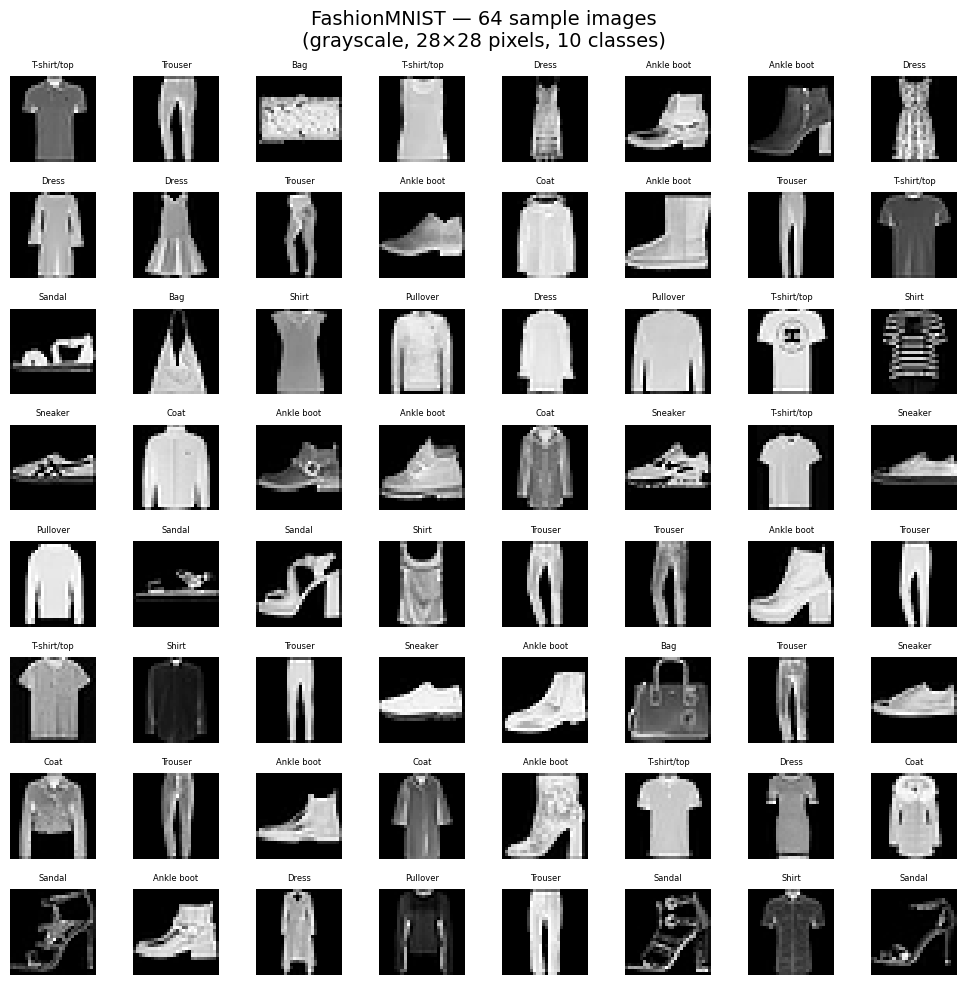

Image dimensions: (1, 28, 28)   (C x H x W)
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [125]:
### Problem 5.C.i: Dataset Visualization
# FashionMNIST classes
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Grab one batch of 64 images
data_iter = iter(train_loader)
images, labels = next(data_iter)
images = images[:64]
labels = labels[:64]

# Plot 64 images in an 8x8 grid
fig, axes = plt.subplots(8, 8, figsize=(10, 10))
fig.suptitle('FashionMNIST — 64 sample images\n(grayscale, 28×28 pixels, 10 classes)', fontsize=14)
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(class_names[labels[i].item()], fontsize=6)
    ax.axis('off')
plt.tight_layout()
plt.show()

print("Image dimensions:", tuple(images[0].shape), "  (C x H x W)")
print("Classes:", class_names)

### Score-matching model

In [126]:
import torch.nn as nn
import torch.nn.functional as F

class GaussianFourierProjection(nn.Module):
    """Gaussian random features for encoding time steps."""
    def __init__(self, embed_dim, scale=30.):
        super().__init__()
        # Randomly sample weights during initialization. These weights are fixed
        # during optimization and are not trainable.
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)


class Dense(nn.Module):
    """A fully connected layer that reshapes outputs to feature maps."""
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.dense = nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.dense(x)[..., None, None]


class ScoreNet(nn.Module):
    """A time-dependent score-based model built upon U-Net architecture."""

    def __init__(self, marginal_proba, channels=[32, 64, 128, 256], embed_dim=256):
        """Initialize a time-dependent score-based network.

        Args:
          marginal_proba: A function that takes time t and gives the standard
            deviation of the perturbation kernel p_{0t}(x(t) | x(0)).
          channels: The number of channels for feature maps of each resolution.
          embed_dim: The dimensionality of Gaussian random feature embeddings.
        """
        super().__init__()
        # Gaussian random feature embedding layer for time
        self.embed = nn.Sequential(GaussianFourierProjection(embed_dim=embed_dim),
             nn.Linear(embed_dim, embed_dim))
        # Encoding layers where the resolution decreases
        self.conv1 = nn.Conv2d(1, channels[0], 3, stride=1, bias=False)
        self.dense1 = Dense(embed_dim, channels[0])
        self.gnorm1 = nn.GroupNorm(4, num_channels=channels[0])
        self.conv2 = nn.Conv2d(channels[0], channels[1], 3, stride=2, bias=False)
        self.dense2 = Dense(embed_dim, channels[1])
        self.gnorm2 = nn.GroupNorm(32, num_channels=channels[1])
        self.conv3 = nn.Conv2d(channels[1], channels[2], 3, stride=2, bias=False)
        self.dense3 = Dense(embed_dim, channels[2])
        self.gnorm3 = nn.GroupNorm(32, num_channels=channels[2])
        self.conv4 = nn.Conv2d(channels[2], channels[3], 3, stride=2, bias=False)
        self.dense4 = Dense(embed_dim, channels[3])
        self.gnorm4 = nn.GroupNorm(32, num_channels=channels[3])

        # Decoding layers where the resolution increases
        self.tconv4 = nn.ConvTranspose2d(channels[3], channels[2], 3, stride=2, bias=False)
        self.dense5 = Dense(embed_dim, channels[2])
        self.tgnorm4 = nn.GroupNorm(32, num_channels=channels[2])
        self.tconv3 = nn.ConvTranspose2d(channels[2] + channels[2], channels[1], 3, stride=2, bias=False, output_padding=1)
        self.dense6 = Dense(embed_dim, channels[1])
        self.tgnorm3 = nn.GroupNorm(32, num_channels=channels[1])
        self.tconv2 = nn.ConvTranspose2d(channels[1] + channels[1], channels[0], 3, stride=2, bias=False, output_padding=1)
        self.dense7 = Dense(embed_dim, channels[0])
        self.tgnorm2 = nn.GroupNorm(32, num_channels=channels[0])
        self.tconv1 = nn.ConvTranspose2d(channels[0] + channels[0], 1, 3, stride=1)

        # The swish activation function
        self.act = lambda x: x * torch.sigmoid(x)
        self.marginal_proba = marginal_proba

    def forward(self, x, t):
        # Obtain the Gaussian random feature embedding for t
        embed = self.act(self.embed(t))
        # Encoding path
        h1 = self.conv1(x)
        ## Incorporate information from t
        h1 += self.dense1(embed)
        ## Group normalization
        h1 = self.gnorm1(h1)
        h1 = self.act(h1)
        h2 = self.conv2(h1)
        h2 += self.dense2(embed)
        h2 = self.gnorm2(h2)
        h2 = self.act(h2)
        h3 = self.conv3(h2)
        h3 += self.dense3(embed)
        h3 = self.gnorm3(h3)
        h3 = self.act(h3)
        h4 = self.conv4(h3)
        h4 += self.dense4(embed)
        h4 = self.gnorm4(h4)
        h4 = self.act(h4)

        # Decoding path
        h = self.tconv4(h4)
        ## Skip connection from the encoding path
        h += self.dense5(embed)
        h = self.tgnorm4(h)
        h = self.act(h)
        h = self.tconv3(torch.cat([h, h3], dim=1))
        h += self.dense6(embed)
        h = self.tgnorm3(h)
        h = self.act(h)
        h = self.tconv2(torch.cat([h, h2], dim=1))
        h += self.dense7(embed)
        h = self.tgnorm2(h)
        h = self.act(h)
        h = self.tconv1(torch.cat([h, h1], dim=1))

        # Normalize output
        _, std = self.marginal_proba(x, t)
        h = h / std[:, None, None, None]
        return h

### Loss function

In [127]:
def loss_fn(model, x, sde, eps=1e-5):
    """ Inputs:
          model: score model (i.e. diffusion model)
          x: batch of images
          sde: instance of VP class
          eps: parameter for numerical stability (1e-5 for learning, 1e-3 for sampling)
    """
    random_t = torch.rand(x.shape[0], device=x.device) * (1. - eps) + eps
    z = torch.randn_like(x, device=x.device)
    mean, std = sde.marginal_prob(x, random_t)
    perturbed_x = mean + z * std[:, None, None, None]

    # predict the score function for each perturbed x in the batch and its corresponding random t
    score = model(perturbed_x, random_t)

    # compute loss
    losses = score * std[:, None, None, None] + z
    loss = torch.mean(torch.sum(losses**2, dim=(1,2,3)))
    return loss

## Train the score model

In [128]:
# VP sde
def train(sde_params):
    beta_min, beta_max = sde_params
    sde = VP(beta_min, beta_max, num_steps)

    score_model = ScoreNet(marginal_proba=sde.marginal_prob)
    score_model = score_model.to(device)
    optimizer = Adam(score_model.parameters(), lr=lr)

    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)
    params_str = '{}_{}'.format(beta_min, beta_max)
    checkpoint_path = checkpoint_dir+'ckpt_{}_{}epochs_{}.pth'.format("fashionmnist", n_epochs, params_str)

    # load checkpoint if existing
    if os.path.exists(checkpoint_path):
        score_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        print("model loaded from checkpoint!")
    # otherwise train from scratch
    else:
        losses = []
        patience = 0
        tqdm_epoch = trange(n_epochs)
        for epoch in tqdm_epoch:
            avg_loss = 0.
            num_items = 0
            for x, y in train_loader:
                x = x.to(device)
                loss = loss_fn(score_model, x, sde)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                avg_loss += loss.item() * x.shape[0]
                num_items += x.shape[0]
            tqdm_epoch.set_description('Average Loss: {:5f}'.format(avg_loss / num_items))
            losses.append(avg_loss/ num_items)

            # Saving: loss need to decrease by 2pts
            if len(losses)>=2:
                if losses[-2] - losses[-1] >= 0.5:
                    torch.save(score_model.state_dict(), checkpoint_path)
                    patience = 0
                else:
                    patience +=1

            # Patience: if no significant improvement in 3 epochs, early stopping
            if patience >= 3:
                break

        plt.figure(figsize=(7, 4))
        plt.plot(range(1, len(losses) + 1), losses, marker='o', markersize=3)
        plt.yscale('log')
        plt.xlabel('Epoch')
        plt.ylabel('Average loss (log scale)')
        plt.title('VP score-matching training loss\n'
                  r'$[\beta_{{min}}, \beta_{{max}}]$ = [{}, {}], lr = {}'.format(
                      beta_min, beta_max, lr))
        plt.grid(True, which='both', alpha=0.3)
        plt.tight_layout()
        plt.show()
    return score_model

## Generation of new samples

In [129]:
from torchvision.utils import make_grid
def plot_images(images):
    sample_grid = make_grid(images, nrow=int(np.sqrt(images.shape[0])))
    plt.figure(figsize=(6,6))
    plt.axis('off')
    plt.imshow(sample_grid.cpu().permute(1, 2, 0).squeeze())
    plt.show()

In [130]:
def setup_for_sampling(sde_params):
    beta_min, beta_max = sde_params
    params_str = '{}_{}'.format(beta_min, beta_max)
    checkpoint_path = checkpoint_dir+'ckpt_{}_{}epochs_{}.pth'.format("fashionmnist", n_epochs, params_str)

    sde = VP(beta_min, beta_max, num_steps)
    score_model = ScoreNet(marginal_proba=sde.marginal_prob)
    score_model = score_model.to(device)
    score_model.eval()
    score_model.load_state_dict(torch.load(checkpoint_path, map_location=device))

    return sde, score_model

### Sampling

Average Loss: 57.324808:  48%|████▊     | 24/50 [08:02<08:42, 20.10s/it]


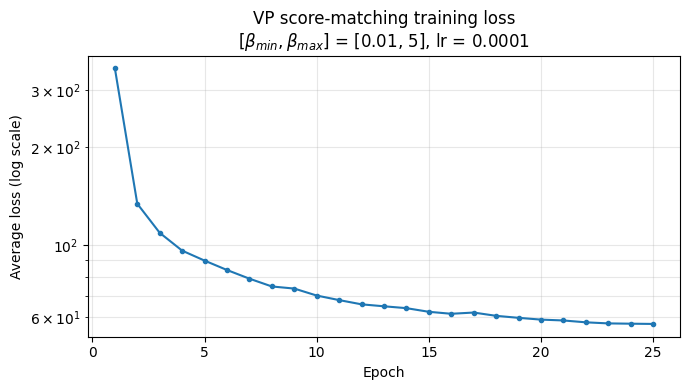

In [131]:
# [beta_min, beta_max]: suggested [0.01, 5] or [0.01, 10]
sde_params = [0.01, 5]
score_model = train(sde_params)
# Build the SDE object so the sampling cells below can access it
sde = VP(sde_params[0], sde_params[1], num_steps)

### Problem 5.C.ii: Training Curves

The cell above trains for up to **50 epochs** with **lr = 1e-4**, **batch size = 64**, **num_steps = 1000**, and VP SDE parameters **[β_min, β_max] = [0.01, 5]**, then plots the per-epoch average loss on a log scale.

**Early stopping / patience strategy (as implemented in `train`):**
- A checkpoint is saved only when the loss improves by at least **0.5** from the previous epoch; this keeps the best model and avoids saving on noisy, non-improving epochs.
- A `patience` counter increments whenever an epoch fails to improve by that 0.5 threshold, and training stops early once `patience >= 3` (i.e. 3 consecutive epochs without significant improvement).

The loss drops steeply during the first several epochs and then flattens into a long, slowly-decreasing tail — the expected behavior for denoising score matching. I used the suggested **[0.01, 5]** schedule and kept the provided hyperparameters; the alternative **[0.01, 10]** schedule injects more noise at large t and can be swapped in via `sde_params`.

100%|██████████| 1000/1000 [00:03<00:00, 288.42it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.36224148..1.26367].


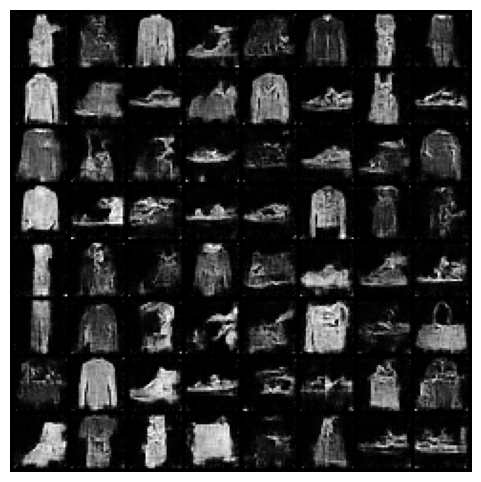

In [132]:
samples = Euler_Maruyama_sampler(score_model, sde, batch_size, num_steps=1000)
plot_images(samples)

100%|██████████| 1000/1000 [00:07<00:00, 142.76it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.31287143..1.5407153].


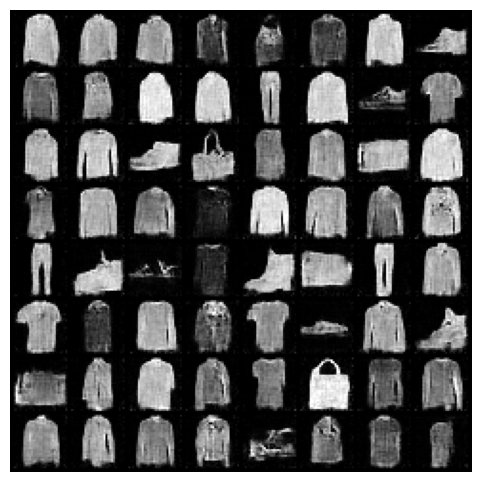

In [133]:
samples = predictor_corrector_sampler(score_model, sde, batch_size, num_steps=1000)
plot_images(samples)

100%|██████████| 1000/1000 [00:19<00:00, 50.42it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.21657375..1.7333299].


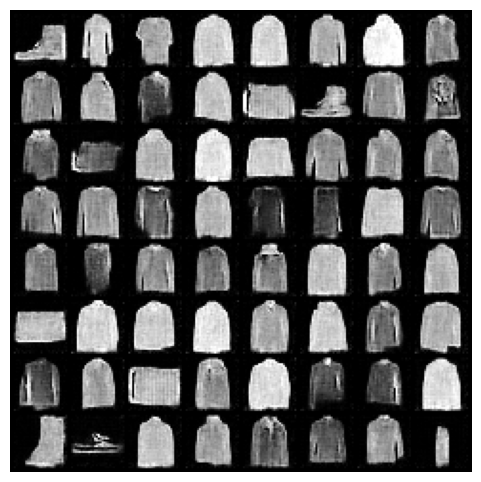

In [134]:
samples = predictor_corrector_sampler(score_model, sde, batch_size, num_corrector_steps=5, num_steps=1000)
plot_images(samples)

### Problem 5.C.v: Qualitative Discussion

The plain **Euler-Maruyama** sampler produces recognizable garment silhouettes but tends to leave a slightly grainier / noisier background, since it takes a single discretized reverse step per time level with no mechanism to correct accumulated discretization error. The **Predictor-Corrector** sampler adds Langevin corrector steps that re-equilibrate the samples toward the score at each noise level, yielding cleaner, smoother images with sharper object boundaries. Increasing the number of corrector steps (e.g. from 1 to 5) further reduces residual noise and improves contrast and detail, at the cost of roughly proportional extra compute. Compared to the FashionMNIST prior visualized in 5.C.i, the model captures the overall global shapes and class-level structure well (trousers, bags, footwear, and tops are clearly distinguishable), but it struggles with fine high-frequency details such as textures, logos, straps, and crisp edges, which appear blurred or smeared.

# Part 4D: Diffusion models for inverse problems

## EC (10pts) : inpainting -- keep until you're done with the pset
This part will require you to read and understand [[Song22]](https://arxiv.org/pdf/2111.08005.pdf) Solving Inverse Problems In Medical Imaging With Score-Based Generative Models.

In our toy example, our measurement matrix A will be an explicit inpainting matrix that replaces some of the pixels in an image by 0 (blackening them out).

Your job will be to modify the sampling process to include conditioning on the perturbed measurements at various t.

**Important: do not attempt until you are entirely satisfied with your work for all of the rest of the assignment (Parts 1 through 5).**

**Important: Minimum guidance will be provided in OH or on Piazza. 🎶🎵You're on your own, kid. You always have been🎵🎶**

**Expectations:** The expected result is a plot with 3 rows: clean images, inpainted images, reconstructed images. The plot **must** include the PSNR of each reconstructed image. You should use at least 5 clean images. We wrote the plotting function for you. We also expect you to explain and justify your implementation choices. Everything (plot, explanations, justifications) **must** appear in your submission PDF.

In [135]:
# helper function to inpaint with 0 pixels and get the subsampling matrix
def inpaint(images, ratio=0.05):
    num_pixels = images.shape[-2] * images.shape[-1]
    num_samples = int(ratio * num_pixels)
    # create subsampling matrix A
    A = torch.eye(num_pixels, device=images.device)
    for pixel in random.sample(range(0, num_pixels), num_samples):
        A[pixel][pixel] = 0
    # black out pixels in images using A (a binary matrix with zeroes where we want to black out pixels)
    inpainted_images = images.clone()
    for i in range(len(images)):
        inpainted_images[i] = torch.reshape(torch.matmul(A, inpainted_images[i].view(num_pixels)), images[0].shape)
    return inpainted_images, A

In [136]:
# helper function to compute the peak signal-to-noise ratio (PSNR)
def psnr(clean, noisy):
    # our range of values is [0.,1.]
    eps = 1e-8
    # TODO: compute psnr
    psnr = None
    return psnr

In [137]:
# helper function to plot samples
def plot_before_after(clean_images, imgs_before, imgs_after, title=""):
    assert(imgs_before.shape[0] == imgs_after.shape[0])
    fig, axs = plt.subplots(3, imgs_before.shape[0], figsize=(16, 10))
    # plot 3 rows: clean, then subsampled, then denoised
    for i, images in enumerate([clean_images, imgs_before, imgs_after]):
        for j, image in enumerate(images):
            axs[i][j].imshow(image.cpu().permute(1, 2, 0).squeeze())
            axs[i][j].set_xticks([])
            axs[i][j].set_yticks([])
    # compute PSNR
    for j, image in enumerate(imgs_after):
        clean = clean_images[j].cpu().permute(1,2,0).squeeze()
        noisy = image.cpu().permute(1,2,0).squeeze()
        psnr_val = psnr(clean, noisy).item()
        axs[2][j].set_title('PSNR: {:.3f}'.format(psnr_val), y=-0.2)
    fig.suptitle(title, size=20)

In [138]:
# helper functions to condition the reverse diffusion
def get_y_t(images, t, marginal_proba):
    # vector of t
    ts = t * torch.ones(images.shape[0], device=images.device)
    ts = ts[:, None, None, None]

    # sample some noise
    z = torch.randn_like(images)

    # perturb at level t
    _, std = marginal_proba(x=0, t=t)
    perturbed_images = images + z * std
    return perturbed_images

def lbda_scheduler(t, lbda, param):
    param = torch.tensor(param)
    f_t = param*t
    lbda = lbda * f_t
    return lbda

def condition_on_inpainted_y(raw_images, x_t, t, marginal_prob_std, A, lbda=.01, lbda_param=10):
    y_t = get_y_t(raw_images, t, marginal_prob_std)
    lbda = lbda_scheduler(t, lbda, param=lbda_param)
    # TODO: YOUR CODE HERE
    P_inv, T = None, None
    # END OF YOUR CODE
    A = A
    # turn images into column vectors
    flat_y_t = torch.flatten(y_t, start_dim=1)
    flat_x_t = torch.flatten(x_t, start_dim=1)
    lbda = lbda[:, None]
    # x_prime is a weighted function of x and y
    y_influence = lbda * torch.matmul(A, torch.matmul(P_inv, flat_y_t.T)).T
    x_influence = (1 - lbda) * torch.matmul(A, torch.matmul(T, flat_x_t.T)).T + \
                  torch.matmul(torch.eye(A.shape[0], device=A.device) - A,
                               torch.matmul(T, flat_x_t.T)).T
    x_t_prime = torch.reshape(y_influence + x_influence, x_t.shape)
    return x_t_prime

In [139]:
# Inpainted images
num_images = None
data, _ = next(iter(train_loader))
clean_images = data[:num_images].to(device)
corrupted_images, A = inpaint(clean_images, ratio=0.75)

# Denoised images
recovered_images = None

# Expected plot
plot_before_after(clean_images, corrupted_images, recovered_images, title="Inverting 75% inpainting on FashionMNIST")

AttributeError: 'NoneType' object has no attribute 'shape'

# Part 5: Diffusion models on a larger scale

As mentioned in the write-up, you only need to include your code for plotting in this notebook for part 5. Here we provide some helper code if you run the experiments here in Google Colab.

### Helper code

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install blobfile mpi4py

#### Change the directory (TODO)

In [ ]:
directory = '/content/drive/MyDrive/path/to/guided-diffusion/repo'

In [ ]:
!wget https://openaipublic.blob.core.windows.net/diffusion/jul-2021/256x256_classifier.pt -P {directory}/models
!wget https://openaipublic.blob.core.windows.net/diffusion/jul-2021/256x256_diffusion_uncond.pt -P {directory}/models
%cd {directory}

In [ ]:
!mv scripts/classifier_sample.py classifier_sample.py

#### Example code for running a script

In [ ]:
import os
# specify directory to save samples
os.environ['OPENAI_LOGDIR'] = '/content/test'

In [ ]:
# define flags
SAMPLE_FLAGS = """
    --batch_size 1
    --num_samples 2
    --timestep_respacing 250
"""
MODEL_FLAGS = """
    --attention_resolutions 32,16,8
    --class_cond False
    --diffusion_steps 1000
    --image_size 256
    --learn_sigma True
    --noise_schedule linear
    --num_channels 256
    --num_head_channels 64
    --num_res_blocks 2
    --resblock_updown True
    --use_fp16 True
    --use_scale_shift_norm True
"""

# run a script
!python classifier_sample.py {MODEL_FLAGS.replace('\n', '')} \
    --classifier_scale 10.0 \
    --classifier_path models/256x256_classifier.pt \
    --model_path models/256x256_diffusion_uncond.pt \
    {SAMPLE_FLAGS.replace('\n', '')}

### A: unconditional generation

In [ ]:
# todo

### B: progression over time visualization

In [ ]:
# todo

### C: interpolation visualization

In [ ]:
# todo

### D: conditional generation

In [ ]:
# todo

### E: conditional generation with different classifier scales

In [ ]:
# todo